# MODEL EVALUATION AND COMPARISON

This notebook compares the performance of multiple machine learning models
(Logistic Regression, Decision Tree, and Random Forest).

In [17]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### Load Saved Models and Recreate Test Split

Load the `.pkl` files exported by each model notebook.
Recreate the same `X_test / y_test` using identical split parameters
(`test_size=0.2, random_state=42`) so predictions match exactly.

In [19]:
# Recreate the same test split
df = pd.read_csv("../data/processed/featured_credit_risk_kh.csv")
X  = df.drop("loan_status", axis=1)
y  = df["loan_status"]

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load saved models 
log_reg = joblib.load("../outputs/models/logistic_regression.pkl")
dt_clf  = joblib.load("../outputs/models/decision_tree.pkl")
rf_clf  = joblib.load("../outputs/models/random_forest.pkl")

# Generate predictions
y_pred_lr = log_reg.predict(X_test)
y_pred_dt = dt_clf.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)

print("Models loaded and predictions generated.")

Models loaded and predictions generated.


### Comparison Table

Compute metrics directly from the loaded models' predictions.

In [20]:
results_df = pd.DataFrame({
    "Model":     ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy":  [accuracy_score(y_test, y_pred_lr),  accuracy_score(y_test, y_pred_dt),  accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_rf)],
    "Recall":    [recall_score(y_test, y_pred_lr),    recall_score(y_test, y_pred_dt),    recall_score(y_test, y_pred_rf)],
    "F1-Score":  [f1_score(y_test, y_pred_lr),        f1_score(y_test, y_pred_dt),        f1_score(y_test, y_pred_rf)],
}).set_index("Model")

results_df.style \
    .format("{:.2%}") \
    .highlight_max(axis=0, color="#2c4c3b") \
    .set_caption("Model Performance Comparison (green = best per metric)")

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,82.26%,71.19%,35.42%,47.30%
Decision Tree,87.82%,72.61%,73.58%,73.09%
Random Forest,92.21%,93.46%,70.27%,80.22%


### Bar Chart Comparison

Visualize all four metrics side-by-side for quick comparison.

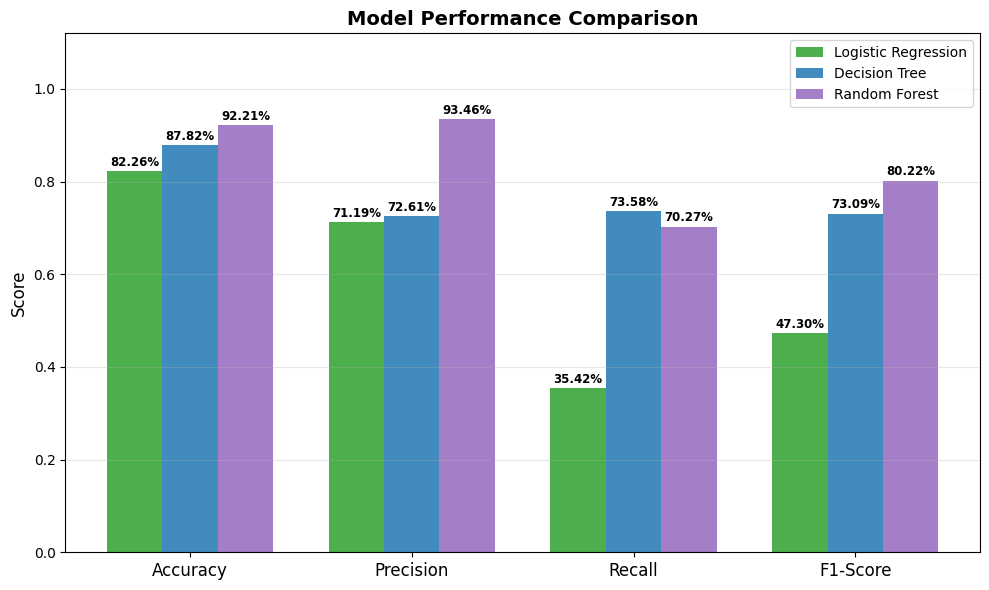

In [21]:
metrics      = ["Accuracy", "Precision", "Recall", "F1-Score"]
model_names  = results_df.index.tolist()
bar_colors   = ["#2ca02c", "#1f77b4", "#9467bd"]  # green, blue, purple

x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, (model, color) in enumerate(zip(model_names, bar_colors)):
    vals = results_df.loc[model].values
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{v:.2%}",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold"
        )

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/models_comparison/comparison_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()

### Display Saved Confusion Matrices

Load the images that were already saved by the individual model notebooks.

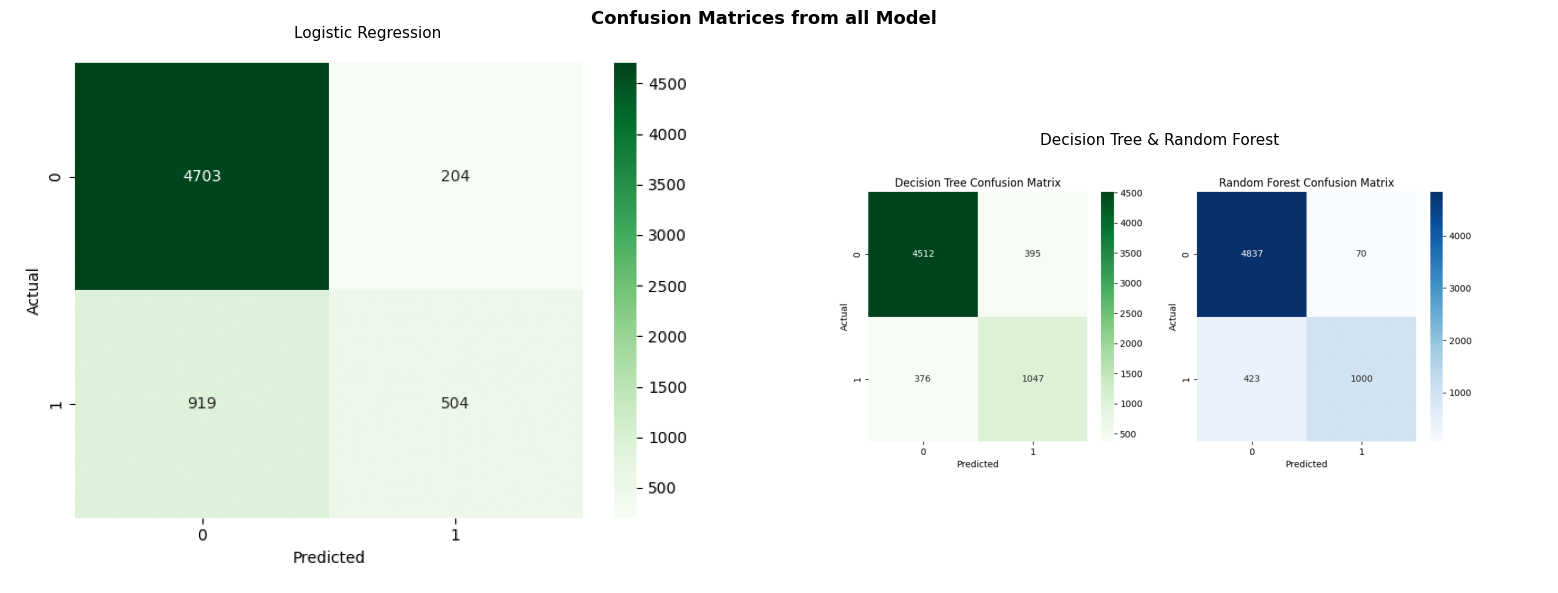

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrices from all Model",
             fontsize=13, fontweight="bold")

img_lr   = mpimg.imread("../outputs/figures/logistic_regression/confusion_matrices_lr.png")
img_dtrf = mpimg.imread("../outputs/figures/Decision_tree-Random_forest/confusion_matrices_dt_rf.png")

axes[0].imshow(img_lr)
axes[0].set_title("Logistic Regression", fontsize=11)
axes[0].axis("off")

axes[1].imshow(img_dtrf)
axes[1].set_title("Decision Tree & Random Forest", fontsize=11)
axes[1].axis("off")

plt.tight_layout()
plt.savefig("../outputs/figures/models_comparison/cofusion_matrices_all.png", dpi=150, bbox_inches="tight")
plt.show()

### Save Comparison Results

Save `results_df` to a `.txt` report.

In [28]:
with open("../outputs/reports/model_comparison_summary.txt", "w") as f:
    f.write("Alternative Credit Scoring — Model Comparison Summary\n")
    f.write("=" * 55 + "\n\n")
    f.write(results_df.to_string(float_format="{:.4f}".format))
    f.write("\n\n")
    f.write("Best per metric:\n")
    for col in results_df.columns:
        best_model = results_df[col].idxmax()
        best_val   = results_df[col].max()
        f.write(f"  {col:<12}: {best_model} ({best_val:.4f})\n")
    f.write("\nRecommended model: Random Forest\n")
    f.write("Reason: Best Accuracy, Precision, and F1-Score.\n")
    f.write("        Decision Tree achieves highest Recall but at the cost of many false positives.\n")

print("Saved to outputs/reports/model_comparison_summary.txt")
print()

Saved to outputs/reports/model_comparison_summary.txt



### Final Summary & Recommendation

| Model | Accuracy | Precision | Recall | F1-Score | Key Observation |
|---|---|---|---|---|---|
| Logistic Regression | 82.26% | 71.18% | 35.41% | 47.30% | Misses 64% of defaulters — too risky for lending |
| Decision Tree | 87.82% | 72.61% | **73.58%** | 73.09% | Best recall, but high false positives (395) |
| **Random Forest** | **92.21%** | **93.46%** | 70.27% | **80.22%** | Best overall balance — recommended model |

#### Model Trade-offs

**Logistic Regression** — Transparent and interpretable, but its linearity limits it. With a Recall of only 35.41%, it missed over 64% of actual defaulters — a serious liability in lending.

**Decision Tree** — Best Recall (73.58%) means it catches more defaulters, but it also generates the most false positives (395), flagging many safe borrowers as risky. Its feature importance was heavily concentrated in `loan_to_income_ratio` (22.55%), suggesting it over-relies on a single threshold.

**Random Forest** — Best overall balance. Its standout 93.46% Precision means it almost never flags a safe borrower as a defaulter. It achieves this without sacrificing too much Recall (70.27%). The distributed feature importance also suggests a more robust and generalizable model.

#### Recommendation

**Recommended model: Random Forest** for deployment in the Cambodian credit scoring context.

- Its high Precision (93.46%) protects safe borrowers from being wrongly denied credit — important for financial inclusion.
- Its solid Recall (70.27%) still catches 7 in 10 actual defaulters.
- Its distributed feature importance confirms that the localized features (land title type, income scaling, stability score) are genuinely contributing to predictions.
